In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

import mujoco
import mujoco.viewer

import numpy as np
import time
import random

from cobot_env import CobotEnv
from soft_actor_critic import SoftActorCritic

In [ ]:
class CobotCubeEnv(CobotEnv):
    def __init__(self, render_mode = None):
        super().__init__(render_mode)
        self.initial_cube_height = self.data.xpos[1][2]
        self.desired_cube_height = 0.2

    def get_distance_reward(self):
        #range here is from distance 0.4 (start), to 0.05 (cube reached)
        #average at 0.15
        gripper_pos = self.data.site_xpos[1]
        cube_pos = self.data.xpos[1]
        cube_distance = np.linalg.norm((gripper_pos-cube_pos))

        distance_reward = -5 * cube_distance  #range(-2, 0.25) avg: 0.75

        if cube_distance <=0.05:
            distance_reward +=0.1
        # approach_pos = cube_pos + np.array([0, 0, 0.1])
        # approach_distance = np.linalg.norm((gripper_pos-approach_pos))
        # cube_reward = -10 * cube_distance # + 3.0
        # transition = np.clip((approach_distance - 0.1) / 0.1, 0, 1)
        # distance_reward = (
        #     transition * approach_reward +
        #     (1 - transition) * cube_reward
        # )
        # velocity_cost = 0.0001 #* np.sum(sim2real(self.data.qvel[-8:])**2)

        return distance_reward, cube_distance

    # def get_orientation_reward(self):
    #     gripper_pos = self.data.site_xpos[1]
    #     cube_pos = self.data.xpos[1]
    #     # approach_pos = cube_pos + np.array([0, 0, 0.1])
    #     cube_distance = np.linalg.norm((gripper_pos-cube_pos))
    #     gripper_rot = self.data.site_xmat[1].reshape(3, 3)[:, 0]
    #     z_axis = np.array([0, 0, -1.0])
    #     to_cube = np.array((cube_pos-gripper_pos)/ cube_distance)
    #     orientation_weight = 0.2 * max(0, (1 - cube_distance/0.4))**2
    #     orientation_reward = (
    #         np.dot(gripper_rot, z_axis) * 1 +
    #         np.dot(gripper_rot, to_cube) * 2.5
    #     ) * orientation_weight  #range (0,0.5) average:0.26
    #     return orientation_reward

    def get_joint_penalty(self):
        #joint penalty
        joint_margin = 2.8
        joint_penalty = (
            max (self.data.qpos[-7]-joint_margin, 0) + 
            max (self.data.qpos[-6]-joint_margin, 0)
        ) * 0.5 #range(0.175, 0)
        return joint_penalty

    def get_bounds_penalty(self):
        gripper_pos = self.data.site_xpos[1]
        gripper_inside = self.check_bounds(gripper_pos, self.gripper_pos_low, self.gripper_pos_high)
        return 0 if gripper_inside else 0.2

    def get_contact_rewards(self):
        left_touch = False
        right_touch = False

        for c in self.data.contact:
            g1, g2 = c.geom1, c.geom2

            if ((g1 == self.cube_geom_id and g2 == self.left_gripper_id) or
                (g2 == self.cube_geom_id and g1 == self.left_gripper_id)):
                left_touch = True

            if ((g1 == self.cube_geom_id and g2 == self.right_gripper_id) or
                (g2 == self.cube_geom_id and g1 == self.right_gripper_id)):
                right_touch = True

        contact_reward = .0 * left_touch + 1.0 * right_touch
        if left_touch and right_touch:
            contact_reward += 1.0 #total 3.0

        return contact_reward, left_touch and right_touch

    # def get_grasp_geometry_reward(self):
    #     cube_pos = self.data.xpos[1]
    #     left_gripper_pos = self.data.geom(self.left_gripper_id).xpos
    #     right_gripper_pos = self.data.geom(self.right_gripper_id).xpos

    #     left_dist = np.linalg.norm(left_gripper_pos - cube_pos)
    #     right_dist = np.linalg.norm(right_gripper_pos - cube_pos)

    #     std = 0.04
    #     left_reward = 1 - np.tanh(left_dist / std)
    #     right_reward = 1 - np.tanh(right_dist / std)

    #     finger_distance = np.linalg.norm(left_gripper_pos - right_gripper_pos) #range 0.1 to 0
    #     cube_distance = abs(finger_distance-0.025) 
    #     distance_reward = 1 - np.tanh( cube_distance / 0.08)

    #     grasp_position_reward = 0.2*(left_reward + right_reward) #range 0.0134 to 0.234 #avg 0.1
    #     # grasp_position_reward -= 0.2 * (self.data.qpos[-1] + self.data.qpos[-2]) #range 0 to 0.05

    #     return grasp_position_reward

    # def get_grasp_geometry_reward(self):
    #     cube_pos = self.data.xpos[1]
    #     L = self.data.geom(self.left_gripper_id).xpos
    #     R = self.data.geom(self.right_gripper_id).xpos

    #     L = L[:2]
    #     R = R[:2]
    #     C = cube_pos[:2]

    #     finger_vec = R - L
    #     finger_dist = np.linalg.norm(finger_vec)

    #     if finger_dist < 1e-6:
    #         return 0.0

    #     finger_dir = finger_vec / finger_dist

    #     t = np.dot(C - L, finger_dir)

    #     # Distance from cube to line connecting fingers
    #     projection = L + t * finger_dir
    #     line_distance = np.linalg.norm(C - projection)

    #     # How centered the cube is between the fingers
    #     center_error = abs(t - finger_dist / 2)

    #     cube_width = 0.05

    #     width_reward   = max(0.0, 1.0 - abs(finger_dist - cube_width) / 0.06)
    #     line_reward    = max(0.0, 1.0 - line_distance / 0.08)
        # center_reward  = max(0.0, 1.0 - center_error / 0.10)


        # return (width_reward + line_reward + center_reward*0.5) * 0.7

    # def get_cube_height_reward(self):
    #     cube_height = self.data.xpos[1][2] - self.initial_cube_height
    #     if cube_height >= 1e-4:
    #         return 6.0 * np.tanh(np.clip(cube_height/self.desired_cube_height, 0, 1))
    #     else:
    #         return 0
        

    def compute_rewards(self):

        distance_reward, cube_distance = self.get_distance_reward()
        # orientation_reward = self.get_orientation_reward()
        joint_penalty = self.get_joint_penalty()
        bounds_penalty = self.get_bounds_penalty()

        # reward = (
        #     distance_reward + orientation_reward 
        #     - joint_penalty - bounds_penalty
        # )

        reward = distance_reward
        # if cube_distance <=0.1:
        #     gate = np.clip((0.12 - cube_distance) / 0.04, 0.0, 1.0)
        #     reward += gate * self.get_grasp_geometry_reward()
        #     contact_reward, contact_present = self.get_contact_rewards()
        #     reward +=contact_reward

        #     if contact_present:
        #         reward+=self.get_cube_height_reward()

        info = {}
        info["success"] = False

        return reward, info

In [3]:
import pickle

# SAVE the current replay buffer
def save_replay_buffer(buffer, filepath="replay_buffer.pkl"):
    with open(filepath, "wb") as f:
        pickle.dump(list(buffer.buffer), f)

# LOAD a replay buffer back into your SAC agent
def load_replay_buffer(buffer, filepath="replay_buffer.pkl"):
    with open(filepath, "rb") as f:
        loaded = pickle.load(f)
    buffer.buffer.clear()
    buffer.buffer.extend(loaded)

In [4]:
env = CobotCubeEnv(render_mode="human")
sac = SoftActorCritic(env)

/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [5]:
checkpoint = torch.load("checkpoints/sac_grasp_2M.pt", map_location=torch.device('cpu')) 
sac.actor.load_state_dict(checkpoint["actor"])
sac.critic.load_state_dict(checkpoint["critic"])
sac.target_critic.load_state_dict(checkpoint["target_critic"])
sac.actor_optimizer.load_state_dict(checkpoint["actor_optimizer"])
sac.critic_optimizer.load_state_dict(checkpoint["critic_optimizer"])

sac.log_alpha.data.copy_(checkpoint["log_alpha"].to(sac.log_alpha.device))
sac.alpha_optimizer.load_state_dict(checkpoint["alpha_optimizer"])

In [6]:
load_replay_buffer(sac.replay_buffer, "2M_run_buffer.pkl")

# print(len(sac.replay_buffer))

num_to_remove = 200_000

for _ in range(num_to_remove):
    sac.replay_buffer.buffer.popleft()

print(len(sac.replay_buffer))

300000


In [7]:
# sac.env = CobotCubeEnv()

/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)


Step 499: -198.08


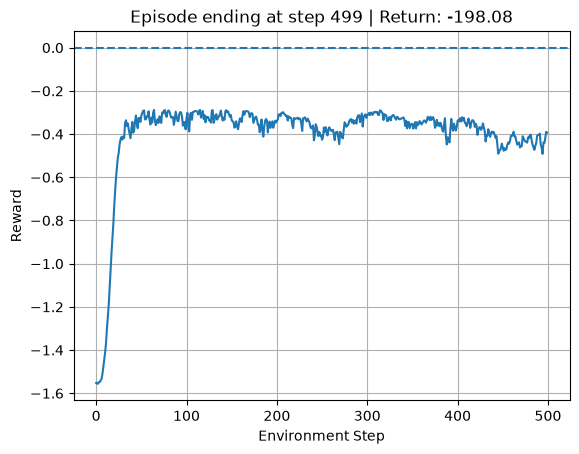

Step 999: -469.46
Step 1308: -94.86
Step 1808: -181.37
Step 2308: -206.98
Step 2808: -192.75
Step 3308: -149.30
Step 3808: -88.05
Step 4308: -255.46
Step 4808: -102.96
Step 5308: -77.54
Step 5808: -261.43
Step 6308: -113.47
Step 6808: -251.84
Step 7308: -231.43
Step 7808: -96.93
Step 8308: -159.09
Step 8808: -386.51
Step 9308: -157.32
Step 9808: -155.95
Step 10308: -640.18
Step 10808: -238.93
Step 11308: -157.14
Step 11808: -383.74
Step 12308: -232.25
Step 12808: -193.41
Step 13308: -218.27
Step 13808: -166.91
Step 14308: -164.98
Step 14808: -236.29


In [ ]:
sac.train_with_plot(1_500_000, resume=True)

#Average training speed
# 3.4k itr/min without rendering
# 1.5k itr/min with rendering

In [ ]:
sac.train(2000,resume=True)

Step 499: -276.36
Step 999: -96.45
Step 1499: -499.55
Step 1999: 371.27


In [ ]:
for i in range(2):
    sac.eval(CobotCubeEnv(render_mode="human"))

/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/aaron-dsouza/programming/miniconda3/envs/mujoco/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)


In [ ]:
torch.save({
    "actor": sac.actor.state_dict(),
    "critic": sac.critic.state_dict(),
    "target_critic": sac.target_critic.state_dict(),
    "log_alpha": sac.log_alpha.detach().cpu(),
    "actor_optimizer": sac.actor_optimizer.state_dict(),
    "critic_optimizer": sac.critic_optimizer.state_dict(),
    "alpha_optimizer": sac.alpha_optimizer.state_dict(),
}, "checkpoints/sac_grasp_4M.pt")

In [ ]:
save_replay_buffer(sac.replay_buffer, "4M_run_buffer.pkl")

: 

In [ ]:
sac.env.render()